# KNN avec PCA et PCA + LDA

Ce notebook implémente deux pipelines de classification KNN :
- **PCA + KNN** : réduction de dimension non supervisée, puis KNN
- **PCA + LDA + KNN** : réduction PCA suivie d'une projection supervisée LDA, puis KNN

Les deux pipelines utilisent SMOTE pour corriger le déséquilibre des classes.

## Imports

On importe toutes les bibliothèques nécessaires pour les deux pipelines.

In [1]:
# pyright: ignore
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from import_ipynb import NotebookFinder  # type: ignore
import importlib
import joblib
import os
import pandas as pd
from huggingface_hub import hf_hub_download
import shutil
from import_ipynb import NotebookFinder  # type: ignore
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score
import importlib
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import numpy as np
import json
from imblearn.over_sampling import SMOTE
import numpy as np
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output
from tenacity import retry, stop_after_attempt, wait_exponential
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

## Chargement des modules utilitaires

On définit les chemins vers les dossiers du projet et on charge les modules `metrics` et `prints` qui contiennent les fonctions d'évaluation et d'affichage.

c:\Tools\python\Lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Tools\python\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/PAR8/chest-xray-pneumonia/resolve/42d3b32e6fc8f1c1974fd14f23bb49e7a130b801/chest-xray-pneumonia.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since PAR8/chest-xray-pneumonia couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Aïda\.cache\huggingface\datasets\PAR8___chest-xray-pneumonia\default\0.0.0\42d3b32e6fc8f1c1974fd14f23bb49e7a130b801 (last modified on Mon Mar  9 21:58:36 2026).



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


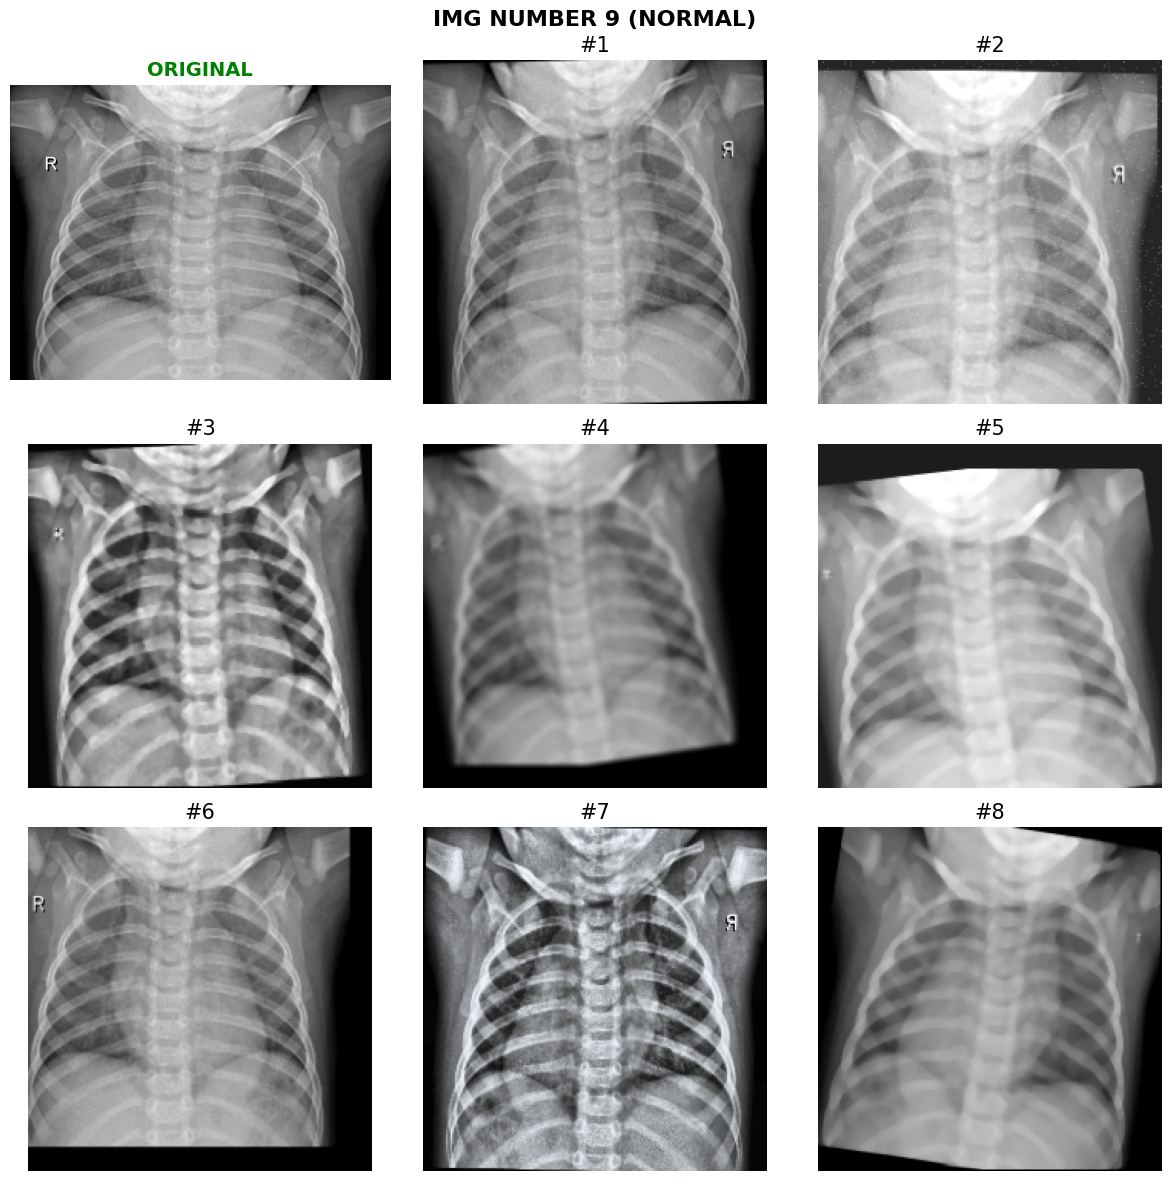


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 1, 0, 0, 0, 1, 2, 2, 1, 0]
Label distribution: [14, 10, 8]


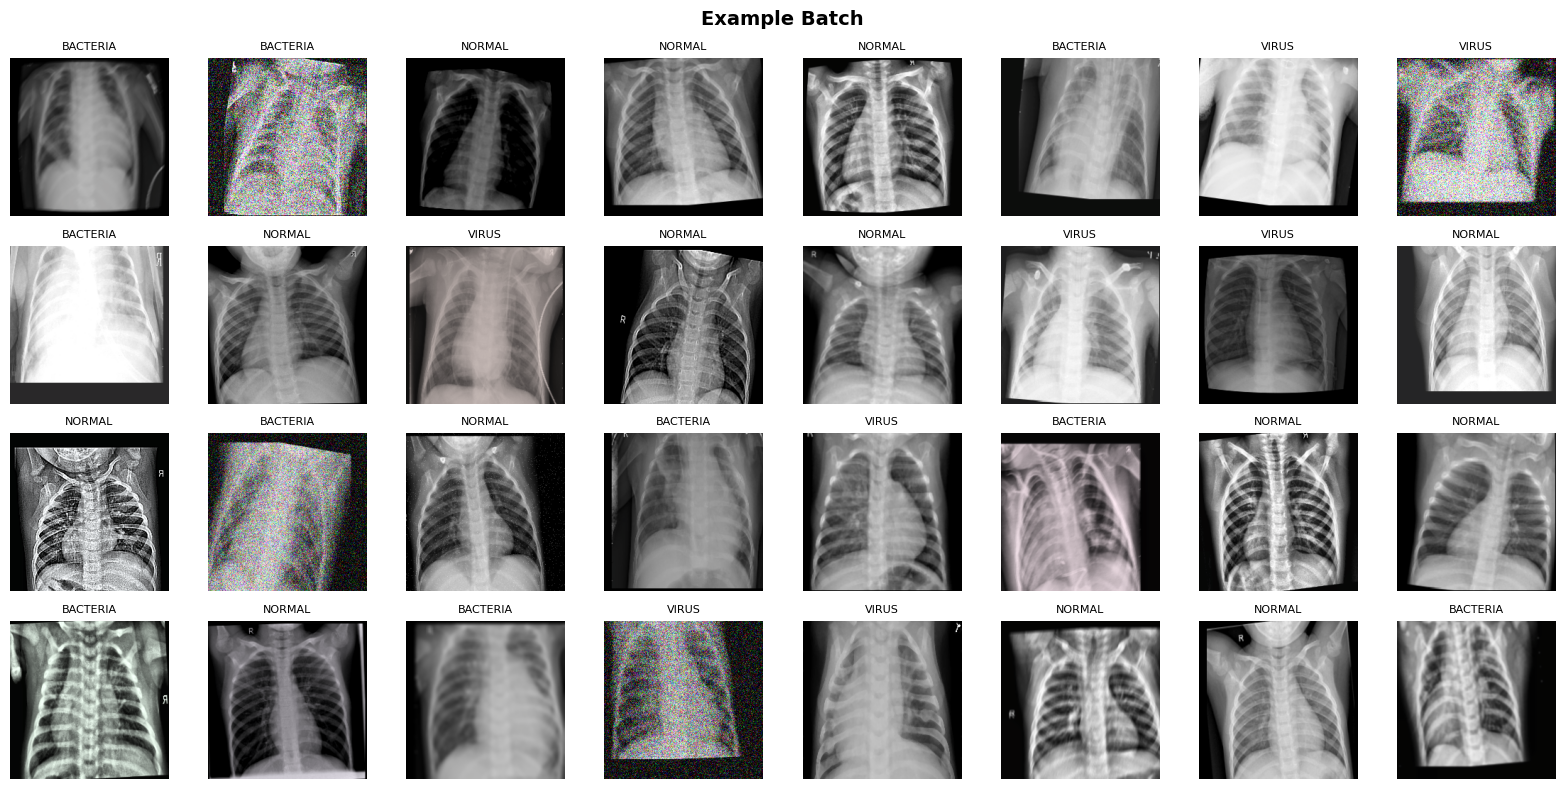

In [2]:
# Retrouver les dossiers
root = r"C:\Travaux\Epitech\Zoidberg2.0"
run_dir = os.path.join(root, "pneumonia_knn" ,"model", "run")
dataset_dir = os.path.join(root, "pneumonia_knn" ,"model", "dataset")
hyperparameter_dir = os.path.join(root, "pneumonia_knn" ,"model", "hyperparameter")

# charger les fichiers
# --- on_the_fly_augmentation.ipynb
spec_on_the_fly_augmentation = NotebookFinder().find_spec("on_the_fly_augmentation", [root])
on_the_fly_augmentation = importlib.util.module_from_spec(spec_on_the_fly_augmentation)
spec_on_the_fly_augmentation.loader.exec_module(on_the_fly_augmentation)

## Utilitaire — Conversion dataset → tableau numpy

Cette fonction parcourt le dataset et aplatit chaque image en un vecteur 1D pour l'utiliser avec sklearn.

In [3]:
def apply_dataset_to_array(dataset, name):
    X = []
    y = []
    for example in tqdm(dataset, desc=f"Processing {name} dataset"):
        img_tensor = example['image']
        img_flattened = np.array(img_tensor).flatten()
        X.append(img_flattened)
        y.append(example['label'])
    return np.array(X), np.array(y)

## Utilitaire — Visualisation des vrais positifs (PNG)

Affiche et sauvegarde un graphique comparant les vrais positifs au total réel par classe.

In [4]:
def true_positives_by_class_png(y_test, y_pred, implementation_name, output_path):
    classes = ['NORMAL', 'BACTERIA', 'VIRUS']
    cm = confusion_matrix(y_test, y_pred)
    
    # Les vrais positifs sont sur la diagonale
    tp = cm.diagonal()
    total = cm.sum(axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    
    x = np.arange(len(classes))
    bars_tp    = ax.bar(x - 0.2, tp,    width=0.4, label='Vrais positifs', color='#22a05a', alpha=0.8)
    bars_total = ax.bar(x + 0.2, total, width=0.4, label='Total réel',     color='#378ADD', alpha=0.8)
    
    # Afficher les valeurs sur les barres
    for bar in bars_tp:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontsize=9)
    for bar in bars_total:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylabel("Nombre d'images", fontsize=9)
    ax.set_title(f"Vrais positifs par classe — {implementation_name}", fontsize=11)
    ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.05)

## Utilitaire — Export des vrais positifs (JSON)

Sauvegarde les résultats de vrais positifs par classe dans un fichier JSON.

In [5]:
def true_positives_by_class_json(y_test, y_pred, implementation_name, output_path):
    classes = ['NORMAL', 'BACTERIA', 'VIRUS']
    cm = confusion_matrix(y_test, y_pred)
    
    tp = cm.diagonal()
    total = cm.sum(axis=1)
    
    results = {
        "implementation": implementation_name,
        "classes": {
            cls: {
                "true_positives": int(tp[i]),
                "total": int(total[i])
            }
            for i, cls in enumerate(classes)
        }
    }
    
    with open(output_path, "w") as f:
        json.dump(results, f, indent=4)

## Utilitaire — Tableau de cross-validation (PNG)

Affiche et sauvegarde sous forme de tableau les métriques obtenues par GridSearchCV, avec surbrillance du meilleur résultat.

In [6]:
def cross_validation_png(grid, implementation_name, output_path):
    results = pd.DataFrame(grid.cv_results_)  # ← ajoute cette ligne
    # Sélectionner les colonnes clés
    table_df = results[[
        'params',
        'mean_test_accuracy',
        'mean_test_precision',
        'mean_test_recall',
        'mean_test_f1',
        'mean_test_roc_auc',
        'rank_test_accuracy'
    ]].copy()
    table_df.insert(0, 'Index CV', [f'#{i+1}' for i in range(len(table_df))])  # ← ici

    # Afficher seulement l'index dans la colonne params
    table_df['params'] = [str(i+1) for i in range(len(table_df))]
    
    # Supprimer la colonne params (redondante avec Index CV)
    table_df = table_df.drop(columns=['params'])

    # Ajuster la taille en fonction du nombre de lignes et colonnes
    num_cols = len(table_df.columns)
    num_rows = len(table_df)
    fig_width = 2 + num_cols * 1.8  # largeur adaptée au nombre de colonnes
    fig_height = 1.5 + num_rows * 0.45  # hauteur adaptée au nombre de lignes
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
        colColours=['#f7f7f7'] + ['#ffffff'] * (num_cols - 1)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Trouver l'indice de la ligne avec rank_test_accuracy = 1
    rank_col_idx = table_df.columns.get_loc('rank_test_accuracy')
    best_rank_row = None
    for i in range(num_rows):
        if table_df.iloc[i, rank_col_idx] == 1:
            best_rank_row = i + 1  # +1 car la ligne 0 est l'en-tête
            break

    # Styliser l'en-tête
    for j in range(num_cols):
        table[(0, j)].set_facecolor('#40466e')
        table[(0, j)].set_text_props(weight='bold', color='white')

    # Alternance de couleur sur les lignes + surbrillance du meilleur rang
    for i in range(1, num_rows + 1):
        for j in range(num_cols):
            if i == best_rank_row:
                # Surbrillance pour le meilleur rang
                table[(i, j)].set_facecolor('#FFD700')  # Doré
                table[(i, j)].set_text_props(weight='bold')
            elif i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')

    plt.title(implementation_name + " Cross-Validation Results", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()

## Utilitaire — Export de cross-validation (JSON)

Sauvegarde tous les résultats de GridSearchCV dans un fichier JSON pour traçabilité.

In [7]:
def cross_validation_json(grid, implementation_name, output_path):
    # Préparer les données à sauvegarder
    results_data = {
        'implementation': implementation_name,
        'best_params': grid.best_params_,
        'best_score': float(grid.best_score_),
        'best_index': int(grid.best_index_),
        'cv_results': {}
    }
    
    # Convertir les colonnes numpy en listes pour la sérialisation JSON
    for key, value in grid.cv_results_.items():
        if hasattr(value, 'tolist'):
            results_data['cv_results'][key] = value.tolist()
        else:
            results_data['cv_results'][key] = value
    
    # Sauvegarder en JSON
    with open(output_path, 'w') as f:
        json.dump(results_data, f, indent=4)

# Test

In [8]:
def plot_knn_prediction_scatter(y_test, y_pred, X_reduced, implementation_name, k=5):
    class_names = ['NORMAL', 'BACTERIA', 'VIRUS']
    colors_pts  = ['#378ADD', '#22a05a', '#EF9F27']
    colors_bg   = ['#b8d4f5', '#a8e8c4', '#fce0a0']

    correct = (y_test == y_pred)

    # ← Réduire à 2D avec PCA pour la visu (X_reduced peut avoir 50+ colonnes)
    pca_visu = PCA(n_components=2)
    X_2d = pca_visu.fit_transform(X_reduced)

    # KNN entraîné dans cet espace 2D uniquement pour les frontières
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d, y_pred)   # ← y_pred, pas y_test

    # Maillage
    h = (X_2d[:, 0].max() - X_2d[:, 0].min()) / 200
    x_min, x_max = X_2d[:, 0].min() - 5, X_2d[:, 0].max() + 5
    y_min, y_max = X_2d[:, 1].min() - 5, X_2d[:, 1].max() + 5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # ... reste de la fonction identique, mais avec X_2d au lieu de X_reduced ...
    cmap_bg  = ListedColormap(colors_bg)
    cmap_pts = ListedColormap(colors_pts)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Projection {implementation_name} — KNN predictions", fontsize=14)

    ax = axes[0]
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8)
    for c, (name, color) in enumerate(zip(class_names, colors_pts)):
        mask = y_test == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,
                   alpha=0.8, s=18, edgecolors='white', linewidths=0.3)
    ax.set_title("Vraie classe")
    ax.set_xlabel("Visu-PC1"); ax.set_ylabel("Visu-PC2"); ax.legend(fontsize=8)

    ax = axes[1]
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8)
    for c, (name, color) in enumerate(zip(class_names, colors_pts)):
        mask = y_pred == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=f"Prédit {name}",
                   alpha=0.8, s=18, edgecolors='white', linewidths=0.3)
    ax.set_title("Prédiction KNN")
    ax.set_xlabel("Visu-PC1"); ax.set_ylabel("Visu-PC2"); ax.legend(fontsize=8)

    ax = axes[2]
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8)
    ax.scatter(X_2d[correct, 0], X_2d[correct, 1], c='#cccccc', alpha=0.4,
               s=12, label='Correct', edgecolors='white', linewidths=0.2)
    ax.scatter(X_2d[~correct, 0], X_2d[~correct, 1], c='#e24b4a', alpha=0.9,
               s=22, label='Erreur', edgecolors='white', linewidths=0.3)
    ax.set_title("Erreurs de prédiction")
    ax.set_xlabel("Visu-PC1"); ax.set_ylabel("Visu-PC2"); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [9]:
run_index = len(os.listdir(run_dir))

In [10]:
hf_token = os.getenv("KEY_HUGGING_FACE")
local_paths = [
    os.path.join(dataset_dir, "dataset_train.pkl"),
    os.path.join(dataset_dir, "dataset_val.pkl"),
    os.path.join(dataset_dir, "dataset_test.pkl")
]

def process_next(index=0):
    # On a traité tous les fichiers
    if index >= len(local_paths):
        display(widgets.HTML("<span style='color: green;'>✅ Tous les fichiers sont prêts !</span>"))
        return

    local_path = local_paths[index]
    filename = os.path.basename(local_path)

    # Si le fichier existe déjà, on passe directement au suivant
    if os.path.exists(local_path):
        process_next(index + 1)
        return

    output = widgets.Output()

    def on_click(val):
        def handler(b):
            with output:
                clear_output()
                if val == 1:
                    try:
                        display(widgets.HTML("<span style='color: green;'>Téléchargement en cours...</span>"))
                        @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
                        def download_model():
                            return hf_hub_download(
                                repo_id="Aidavef/chest-xray-pneumonia",
                                filename=f"KNN/models/v1/{filename}",
                                repo_type="model",
                                token=hf_token,
                                local_dir=dataset_dir,
                                local_files_only=False,
                                cache_dir=None
                            )
                        cached_path = download_model()
                        dest_path = os.path.join(dataset_dir, filename)
                        shutil.move(cached_path, dest_path)
                        shutil.rmtree(os.path.join(dataset_dir, "KNN"), ignore_errors=True)
                        shutil.rmtree(os.path.join(dataset_dir, ".cache"), ignore_errors=True)
                        display(widgets.HTML("<span style='color: green;'>✓ Téléchargement terminé</span>"))
                    except Exception as e:
                        display(widgets.HTML(f"<span style='color: red;'>Erreur : {e}</span>"))

                elif val == 2:
                    display(widgets.HTML("<span style='color: green;'>Preprocessing en cours...</span>"))
                    if filename == "dataset_train.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.train_data,"train"), local_path)
                    elif filename == "dataset_test.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.test_data,"test"), local_path)
                    elif filename == "dataset_val.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.val_data,"val"), local_path)
                    display(widgets.HTML("<span style='color: green;'>✓ Preprocessing terminé</span>"))

            # ✅ On passe au fichier suivant après l'action
            process_next(index + 1)

        return handler

    btn1 = widgets.Button(description="Télécharger depuis Hugging Face (-1min)", button_style="info", layout=widgets.Layout(width="300px", margin="10px 20px 15px 20px"))
    btn2 = widgets.Button(description="Lancer le preprocessing", button_style="info", layout=widgets.Layout(width="300px", margin="10px 20px 15px 20px"))

    btn1.on_click(on_click(1))
    btn2.on_click(on_click(2))

    title = widgets.HTML(f"Le fichier <b>{filename}</b> est manquant. Que souhaitez-vous faire ?")
    box = widgets.HBox([btn1, btn2], layout=widgets.Layout(justify_content="center"))

    display(title, box, output)

process_next()

HTML(value="<span style='color: green;'>✅ Tous les fichiers sont prêts !</span>")

In [11]:
X_train, y_train = joblib.load(f'{dataset_dir}/dataset_train.pkl')
X_val, y_val = joblib.load(f'{dataset_dir}/dataset_val.pkl')
X_test, y_test = joblib.load(f'{dataset_dir}/dataset_test.pkl')

---
# Pipeline PCA + KNN

## Création du pipeline

On crée un pipeline avec deux étapes : la réduction de dimension avec PCA, puis la classification avec KNN.

Les hyperparamètres testés sont :
- `pca__n_components` : 0.95 (on garde 95% de la variance)
- `knn__n_neighbors` : 3, 5, 9
- `knn__metric` : euclidean, manhattan
- `knn__weights` : distance
- `knn__algorithm` : ball_tree

In [12]:
# Pipeline PCA + KNN
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),  # ← ajouter ça
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# Hyperparamètres à tester
param_grid_pca = {
        'pca__n_components': [0.95, 0.99],
    'knn__n_neighbors': [5, 9, 15],
    'knn__metric': ['euclidean'],
    'knn__weights': ['distance'],
    'knn__algorithm': ['brute']
}
# Configuration des métriques pour GridSearchCV
scoring = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, average='weighted'),
    'recall':    make_scorer(recall_score,    average='macro'),
    'f1':        make_scorer(f1_score,        average='weighted'),
    'roc_auc':   make_scorer(roc_auc_score,   response_method="predict_proba", average='macro', multi_class='ovo')
}

## GridSearchCV — PCA + KNN

On lance une recherche par grille pour trouver les meilleurs hyperparamètres. Si le fichier `.pkl` existe déjà, on le charge directement pour éviter de tout relancer.

In [13]:
import threading

event = threading.Event()

file_name_pca = "knn_pca_grid_search"
path_hyperparameter_pca = f'{hyperparameter_dir}/{file_name_pca}_{run_index}.pkl'

def run_cross_validation_pca_knn():
    display(widgets.HTML("<span style='color: green;'>Process : Cross Validation - PCA + KNN</span>"))
    grid_pca = GridSearchCV(
        estimator=pipeline_pca,
        param_grid=param_grid_pca,
        cv=2,
        scoring=scoring,
        refit='recall',
        n_jobs=1,
        verbose=2
    )
    grid_pca.fit(X_train, y_train)
    os.makedirs(hyperparameter_dir, exist_ok=True)
    joblib.dump(grid_pca, path_hyperparameter_pca)

if not os.path.exists(path_hyperparameter_pca):
    run_cross_validation_pca_knn()

grid_pca = joblib.load(path_hyperparameter_pca)
display(widgets.HTML(
    f"✅ Chargé : <span style='color: blue;'></span>"
))

HTML(value="<span style='color: green;'>Process : Cross Validation - PCA + KNN</span>")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.95; total time= 1.9min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.95; total time= 1.8min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.99; total time= 2.0min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.99; total time= 1.9min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca__n_components=0.95; total time= 1.6min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca__n_components=0.95; total time= 2.1min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca

HTML(value="✅ Chargé : <span style='color: blue;'></span>")

## Transformation PCA

On extrait la transformation PCA du meilleur modèle pour obtenir les données réduites.
Ces représentations servent à l'analyse et au rééquilibrage avec SMOTE — elles ne sont **pas** passées directement au pipeline pour prédire.

In [14]:
X_train_pca = grid_pca.best_estimator_.named_steps['pca'].transform(X_train)
X_test_pca  = grid_pca.best_estimator_.named_steps['pca'].transform(X_test) 

## Rééquilibrage — SMOTE

La classe NORMAL est sous-représentée, ce qui biaise le KNN vers BACTERIA. On applique **SMOTE** (*Synthetic Minority Over-sampling Technique*) pour générer synthétiquement de nouveaux exemples des classes minoritaires jusqu'à équilibrer les effectifs.

> ⚠️ SMOTE s'applique uniquement sur `X_train_pca` (après PCA), jamais sur `X_test_pca`.

In [15]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

unique, counts = np.unique(y_train_resampled, return_counts=True)
print("Effectifs après SMOTE :")
for cls, cnt in zip(unique, counts):
    print(f"  Classe {cls} : {cnt} exemples")

Effectifs après SMOTE :
  Classe 0 : 2362 exemples
  Classe 1 : 2362 exemples
  Classe 2 : 2362 exemples


## Prédictions — PCA + KNN + SMOTE

On réentraîne le meilleur KNN (extrait du pipeline) sur les données rééquilibrées par SMOTE, puis on prédit sur `X_test_pca`.

> Le pipeline complet (`knn_pca.predict(X_test)`) n'est pas utilisé ici car SMOTE n'est pas intégré dans le pipeline — on passe directement `X_test_pca` au KNN.

In [16]:
# Extraire le meilleur KNN du pipeline et le réentraîner sur données SMOTE
best_knn_params = grid_pca.best_params_
knn_pca = KNeighborsClassifier(
    n_neighbors = best_knn_params['knn__n_neighbors'],
    metric      = best_knn_params['knn__metric'],
    weights     = best_knn_params['knn__weights'],
    algorithm   = best_knn_params['knn__algorithm']
    
)
knn_pca.fit(X_train_resampled, y_train_resampled)

y_pred_pca = knn_pca.predict(X_test_pca)  # type: ignore

## Résultats — PCA + KNN

On affiche les résultats de la validation croisée sous forme de tableau et on les sauvegarde en JSON.

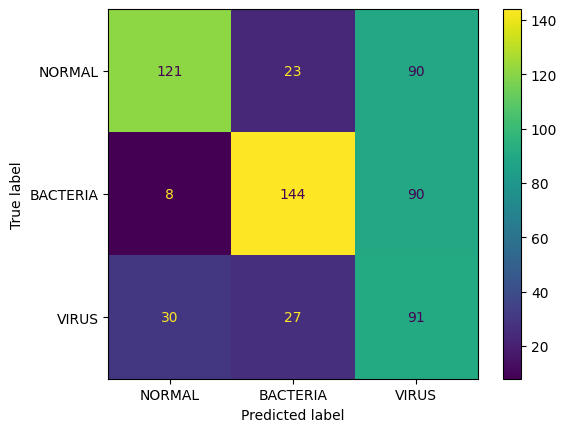

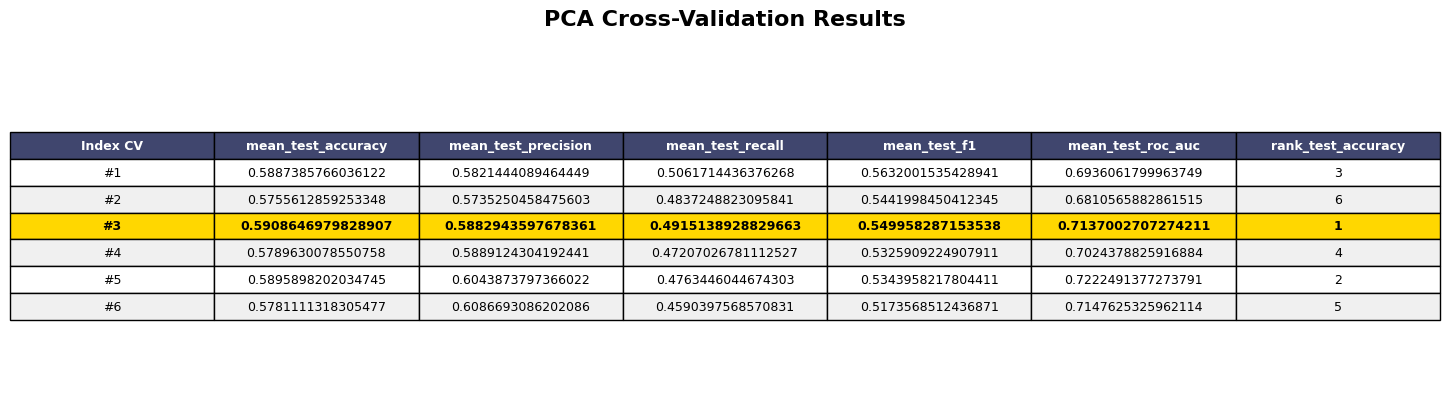

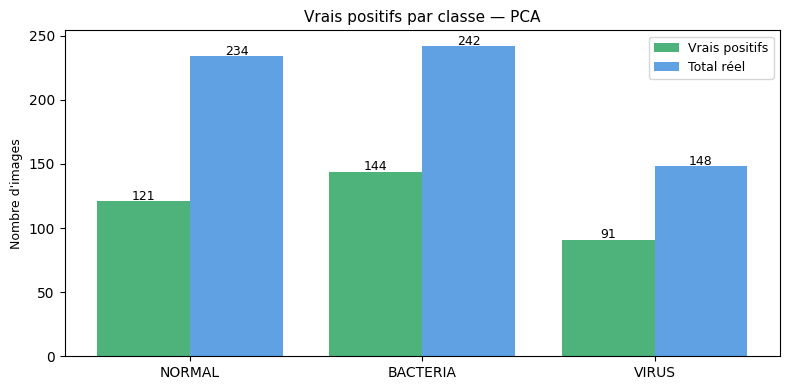

<Figure size 640x480 with 0 Axes>

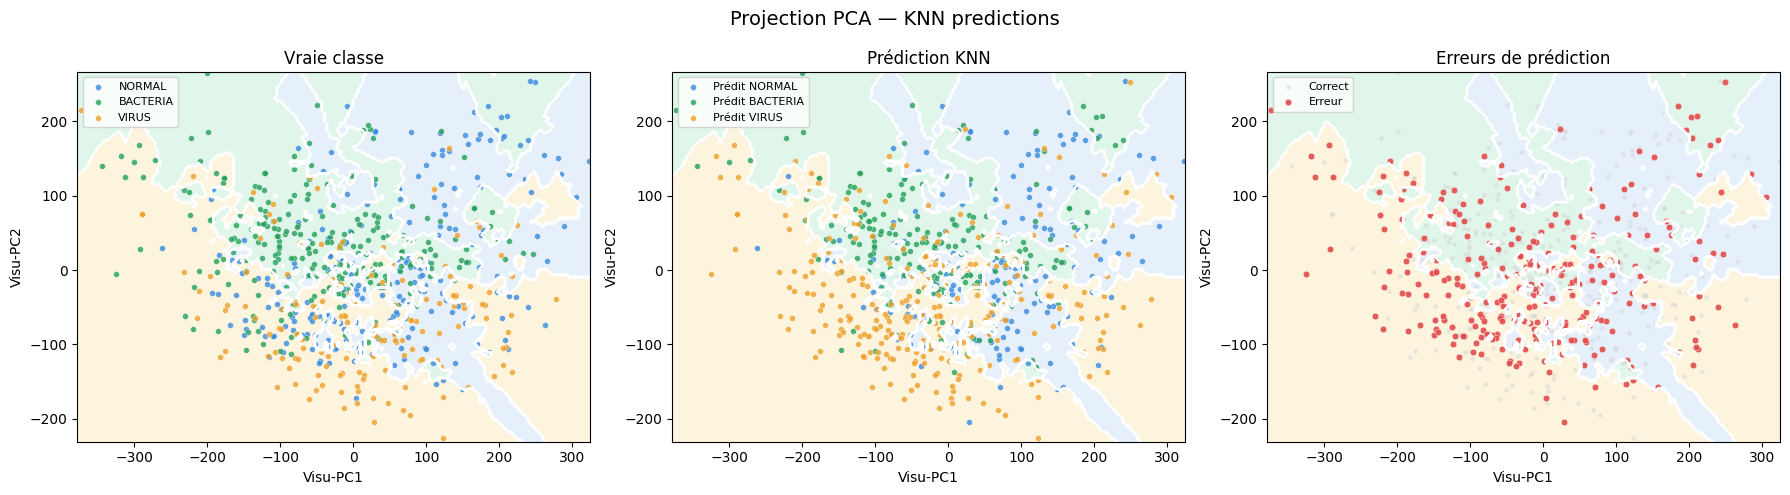

In [17]:
# Creer les dossiers de résultats
os.makedirs(f'{run_dir}/run_{run_index}', exist_ok=True)
path_run = f'{run_dir}/run_{run_index}'

cm = confusion_matrix(y_test, y_pred_pca)
disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'BACTERIA', 'VIRUS'])
disp.plot()

cross_validation_png(grid_pca, "PCA", f'{path_run}/cross_validation_pca.png')
cross_validation_json(grid_pca, "PCA", f'{path_run}/cross_validation_pca.json')

true_positives_by_class_png(y_test, y_pred_pca, "PCA", f'{path_run}/true_positives_by_class_pca.png')
true_positives_by_class_json(y_test, y_pred_pca, "PCA", f'{path_run}/true_positives_by_class_pca.json')

plot_knn_prediction_scatter(y_test, y_pred_pca, X_test_pca, "PCA")


---
# Pipeline PCA + LDA + KNN

## Création du pipeline

On ajoute LDA après PCA pour maximiser la séparation entre classes avant de passer au KNN.
LDA est supervisé : il projette les données sur les axes qui maximisent la variance inter-classes
et minimisent la variance intra-classes.

Les hyperparamètres testés sont :
- `pca__n_components` : 0.95, 0.99
- `knn__n_neighbors` : 5, 9, 15
- `knn__metric` : euclidean
- `knn__weights` : distance
- `knn__algorithm` : brute

In [18]:
# Pipeline PCA + LDA + KNN
pipeline_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('lda', LDA(solver='eigen', shrinkage='auto')),  # ← plus stable
    ('knn', KNeighborsClassifier())
])

# Hyperparamètres à tester
param_grid_lda = {
    'pca__n_components': [0.95, 0.99],
    'knn__n_neighbors': [5, 9, 15],
    'knn__metric': ['euclidean'],
    'knn__weights': ['distance'],
    'knn__algorithm': ['brute']
}

## GridSearchCV — PCA + LDA + KNN

On lance la recherche par grille. Si le fichier `.pkl` existe déjà, on le charge directement.

In [19]:
file_name_lda = "knn_pca_lda_grid_search"
path_hyperparameter_lda = f'{hyperparameter_dir}/{file_name_lda}_{run_index}.pkl'

def run_cross_validation_lda_knn():
    display(widgets.HTML("<span style='color: green;'>Process : Cross Validation - PCA + LDA + KNN</span>"))
    grid_lda = GridSearchCV(
        estimator=pipeline_lda,
        param_grid=param_grid_lda,
        cv=2,
        scoring=scoring,
        refit='recall',
        n_jobs=1,
        verbose=2
    )
    grid_lda.fit(X_train, y_train)
    os.makedirs(hyperparameter_dir, exist_ok=True)
    joblib.dump(grid_lda, path_hyperparameter_lda)

if not os.path.exists(path_hyperparameter_lda):
    run_cross_validation_lda_knn()

grid_lda = joblib.load(path_hyperparameter_lda)
display(widgets.HTML(
    f"✅ Chargé : <span style='color: blue;'></span>"
))

HTML(value="<span style='color: green;'>Process : Cross Validation - PCA + LDA + KNN</span>")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.95; total time= 1.6min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.95; total time= 1.9min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.99; total time= 1.8min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance, pca__n_components=0.99; total time= 2.0min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca__n_components=0.95; total time= 1.9min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca__n_components=0.95; total time= 1.9min
[CV] END knn__algorithm=brute, knn__metric=euclidean, knn__n_neighbors=9, knn__weights=distance, pca

HTML(value="✅ Chargé : <span style='color: blue;'></span>")

## Transformation PCA + LDA

On extrait la transformation complète (PCA → LDA) du meilleur modèle.
LDA avec 3 classes produit au maximum 2 composantes discriminantes — parfait pour la visualisation.

> Ces représentations servent à SMOTE et à la visualisation. Elles ne sont **pas** passées au pipeline.

In [20]:
X_train_lda = grid_lda.best_estimator_.named_steps['lda'].transform(
    grid_lda.best_estimator_.named_steps['pca'].transform(X_train)
)
X_test_lda = grid_lda.best_estimator_.named_steps['lda'].transform(
    grid_lda.best_estimator_.named_steps['pca'].transform(X_test)
)

print(f"Dimensions après PCA + LDA : train={X_train_lda.shape}, test={X_test_lda.shape}")

Dimensions après PCA + LDA : train=(4705, 2), test=(624, 2)


## Rééquilibrage — SMOTE

On applique SMOTE sur les données transformées PCA + LDA pour rééquilibrer les classes.

> ⚠️ SMOTE s'applique uniquement sur `X_train_lda`, jamais sur `X_test_lda`.

In [21]:
smote_lda = SMOTE(random_state=42)
X_train_lda_resampled, y_train_lda_resampled = smote_lda.fit_resample(X_train_lda, y_train)

unique, counts = np.unique(y_train_lda_resampled, return_counts=True)
print("Effectifs après SMOTE (LDA) :")
for cls, cnt in zip(unique, counts):
    print(f"  Classe {cls} : {cnt} exemples")

Effectifs après SMOTE (LDA) :
  Classe 0 : 2362 exemples
  Classe 1 : 2362 exemples
  Classe 2 : 2362 exemples


## Prédictions — PCA + LDA + KNN + SMOTE

On réentraîne le meilleur KNN sur les données rééquilibrées, puis on prédit sur `X_test_lda`.

In [22]:
best_knn_params_lda = grid_lda.best_params_
knn_lda = KNeighborsClassifier(
    n_neighbors = best_knn_params_lda['knn__n_neighbors'],
    metric      = best_knn_params_lda['knn__metric'],
    weights     = best_knn_params_lda['knn__weights'],
    algorithm   = best_knn_params_lda['knn__algorithm']
)
knn_lda.fit(X_train_lda_resampled, y_train_lda_resampled)

y_pred_lda = knn_lda.predict(X_test_lda)  # type: ignore

## Résultats — PCA + LDA + KNN

On affiche les résultats et on les sauvegarde.

> Ici `X_test_lda` est déjà en 2D (LDA avec 3 classes → 2 composantes max),
> donc la visualisation des frontières est directe sans re-projection supplémentaire.

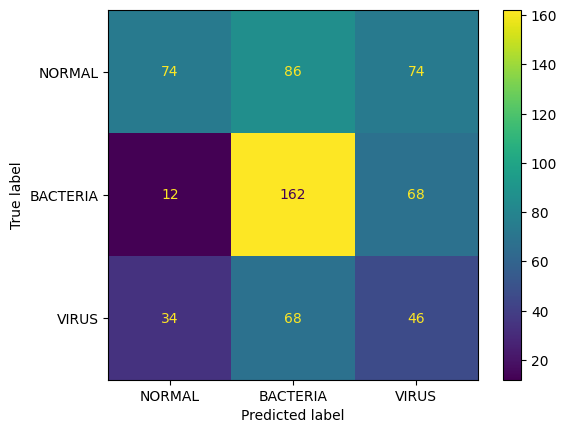

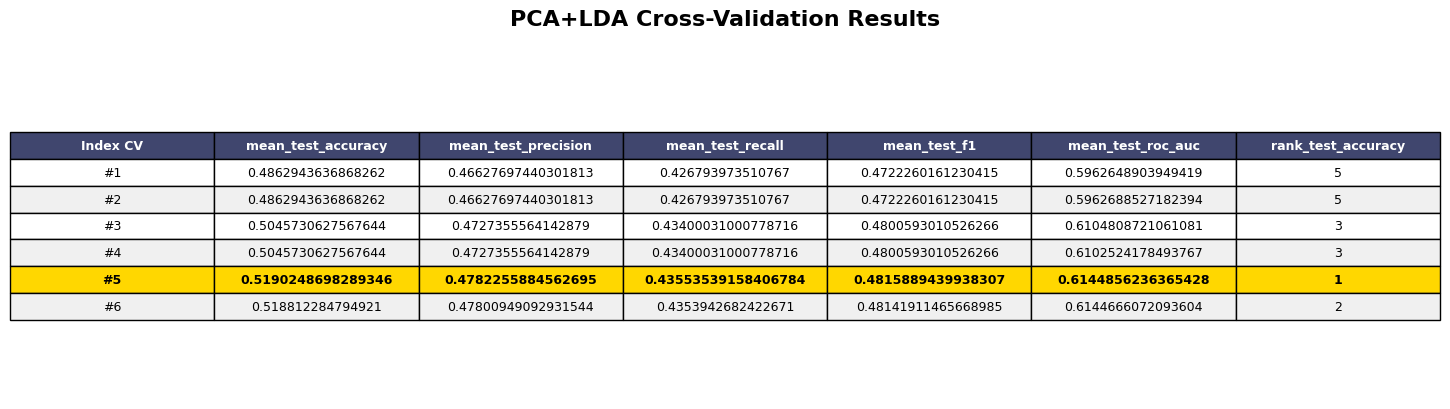

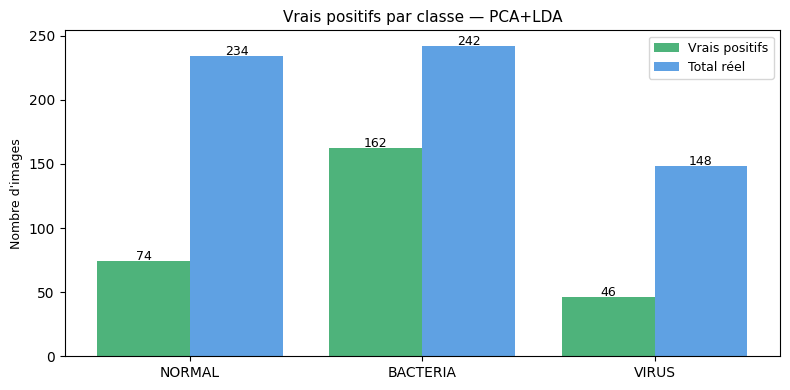

<Figure size 640x480 with 0 Axes>

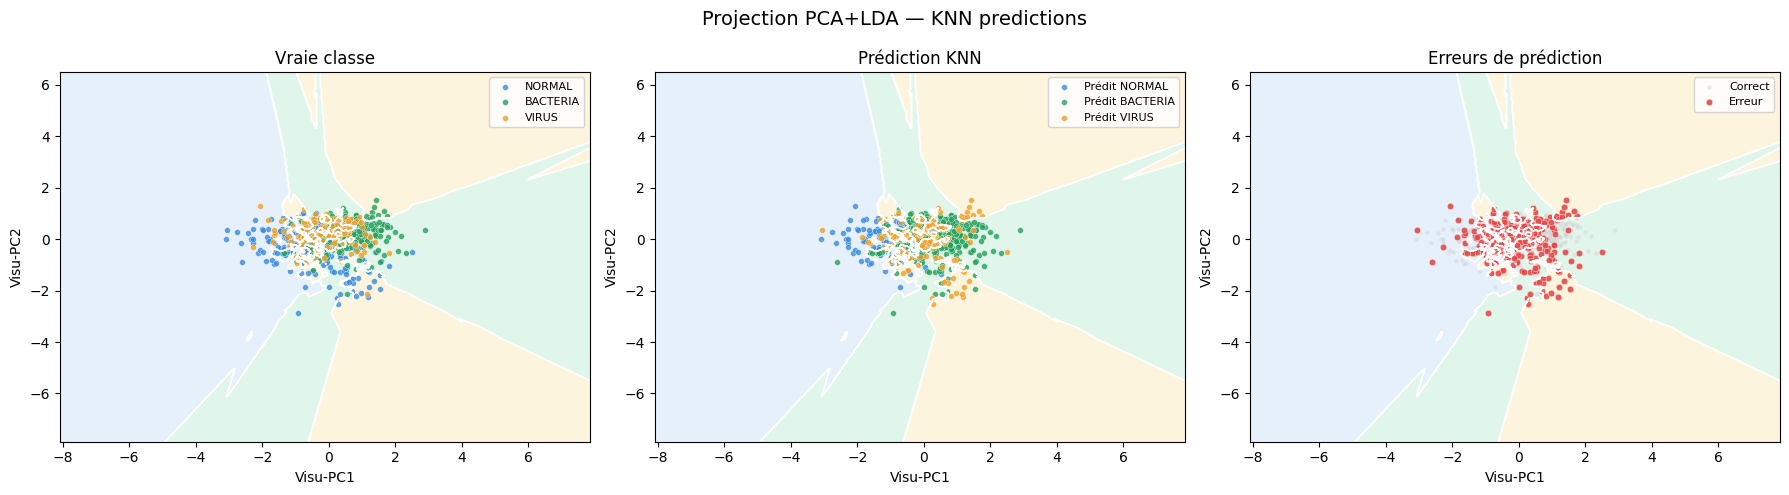

In [23]:
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp_lda = ConfusionMatrixDisplay(cm_lda, display_labels=['NORMAL', 'BACTERIA', 'VIRUS'])
disp_lda.plot()

cross_validation_png(grid_lda, "PCA+LDA", f'{path_run}/cross_validation_lda.png')
cross_validation_json(grid_lda, "PCA+LDA", f'{path_run}/cross_validation_lda.json')

true_positives_by_class_png(y_test, y_pred_lda, "PCA+LDA", f'{path_run}/true_positives_by_class_lda.png')
true_positives_by_class_json(y_test, y_pred_lda, "PCA+LDA", f'{path_run}/true_positives_by_class_lda.json')

# X_test_lda est déjà en 2D → on le passe directement (pas besoin de re-projection)
plot_knn_prediction_scatter(y_test, y_pred_lda, X_test_lda, "PCA+LDA")
